In [146]:
import pandas as pd
import numpy as np

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Lasso, LassoCV

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



In [56]:
def assign_age_group(age):
    """
    Assigns a respondent to an age group based on their age.

    Parameters:
        age (int or float): The respondent's age.

    Returns:
        str: The age group label used for retirement readiness analysis.
    """
    if age < 30:
        return "Under 30"
    elif age < 40:
        return "30-39"
    elif age < 50:
        return "40-49"
    elif age < 60:
        return "50-59"
    elif age < 65:
        return "60-64"
    else:
        return "65+"
    

def retirement_multiplier(age):
    """
    Returns the retirement savings multiplier associated with a respondent's age.

    The multiplier represents the estimated amount of retirement liquidity
    a respondent should have saved as a multiple of annual income for their
    age group. These thresholds are intentionally moderate because the measure
    focuses only on retirement liquidity, not total net worth, Social Security,
    pensions, or home equity.

    Parameters:
        age (int or float): The respondent's age.

    Returns:
        float: The retirement readiness multiplier for the respondent's age group.
    """
    if age < 30:
        return 0.25
    elif age < 40:
        return 0.75
    elif age < 50:
        return 2
    elif age < 60:
        return 4
    elif age < 65:
        return 6
    else:
        return 8

Because the dependent variable focuses specifically on retirement liquidity rather than total household wealth, moderate age-adjusted income multiples were used to avoid overstating retirement risk. The thresholds still increase by age group, but they are lower than full retirement savings benchmarks that often assume broader measures of wealth, pensions, Social Security, or home equity.

In [57]:
df = pd.read_csv('../data/processed/Cleaned_SCF_2022.csv', index_col=0)
df.shape

(4595, 12)

In [58]:
df.head()

,LOG_RETQLIQ,EDUC,HHOUSES,EMERGSAV,FINLIT,AGE,LOG_EQUITY,LOG_FIN,LOG_LIQ,LOG_INCOME,LOG_DEBT,LOG_STOCKS
0,12.409018,9,1,1,1,70,10.799596,12.461106,9.480444,10.566323,12.180760,0.000000
5,11.512935,12,1,1,3,46,10.308986,11.852970,10.609082,12.323103,13.159083,0.000000
10,13.036808,14,1,1,3,68,17.917856,17.918036,9.295692,13.006586,16.682273,17.904508
15,14.220309,12,0,1,3,74,14.360158,14.587007,12.007628,11.934327,0.000000,0.000000
20,0.000000,8,0,0,0,19,0.000000,7.003974,7.003974,10.936822,9.305741,0.000000


In [59]:
df.columns

Index(['LOG_RETQLIQ', 'EDUC', 'HHOUSES', 'EMERGSAV', 'FINLIT', 'AGE',
       'LOG_EQUITY', 'LOG_FIN', 'LOG_LIQ', 'LOG_INCOME', 'LOG_DEBT',
       'LOG_STOCKS'],
      dtype='str')

verify age group and multiplier are working as expected

In [60]:
df["AGE_GROUP"] = df["AGE"].apply(assign_age_group)
df["RET_MULTIPLIER"] = df["AGE"].apply(retirement_multiplier)

df[["AGE", "AGE_GROUP", "RET_MULTIPLIER"]].head()

,AGE,AGE_GROUP,RET_MULTIPLIER
0,70,65+,8.00
5,46,40-49,2.00
10,68,65+,8.00
15,74,65+,8.00
20,19,Under 30,0.25


create classification target

In [61]:
df["INCOME_RAW_EST"] = np.expm1(df["LOG_INCOME"])
df["RETQLIQ_RAW_EST"] = np.expm1(df["LOG_RETQLIQ"])

df["RET_READY_THRESHOLD"] = df["INCOME_RAW_EST"] * df["RET_MULTIPLIER"]

df["RET_READY"] = np.where(
    df["RETQLIQ_RAW_EST"] >= df["RET_READY_THRESHOLD"],
    1,
    0
)

verify classification is working

In [62]:
df[[
    "AGE",
    "AGE_GROUP",
    "LOG_INCOME",
    "INCOME_RAW_EST",
    "RET_MULTIPLIER",
    "RET_READY_THRESHOLD",
    "LOG_RETQLIQ",
    "RETQLIQ_RAW_EST",
    "RET_READY"
]].head()

,AGE,AGE_GROUP,LOG_INCOME,INCOME_RAW_EST,RET_MULTIPLIER,RET_READY_THRESHOLD,LOG_RETQLIQ,RETQLIQ_RAW_EST,RET_READY
0,70,65+,10.566323,38804.734469,8.00,3.104379e+05,12.409018,245000.0,0
5,46,40-49,12.323103,224829.659320,2.00,4.496593e+05,11.512935,100000.0,0
10,68,65+,13.006586,445335.671340,8.00,3.562685e+06,13.036808,459000.0,0
15,74,65+,11.934327,152408.567130,8.00,1.219269e+06,14.220309,1499000.0,1
20,19,Under 30,10.936822,56207.414830,0.25,1.405185e+04,0.000000,0.0,0


In [63]:
df["RET_READY"].value_counts()

RET_READY
0    4171
1     424
Name: count, dtype: int64

In [64]:
df["RET_READY"].value_counts(normalize=True).round(3)

RET_READY
0    0.908
1    0.092
Name: proportion, dtype: float64

The age-adjusted retirement readiness target classified approximately 9.2% of respondents as retirement ready and 90.8% as not retirement ready. This indicates that the classification target is highly imbalanced, so later classification models should be evaluated using precision, recall, F1-score, and possibly class-weighted models instead of relying on accuracy alone.

## Baseline Model

In [106]:
regression_features = [
    # financial
    'LOG_EQUITY',
    'LOG_FIN',
    'LOG_LIQ',
    'LOG_INCOME',
    'LOG_DEBT',
    'LOG_STOCKS',
    # socioeconomic 
    'EDUC',
    'FINLIT',
    'AGE'
]

target = 'LOG_RETQLIQ'

In [107]:
X = df[regression_features]
y = df[target]

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [109]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3676, 9), (919, 9), (3676,), (919,))

In [110]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [111]:
y_pred = lr.predict(X_test)

In [112]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Linear Regression")
print("R²:", r2)
print("RMSE:", rmse)

Baseline Linear Regression
R²: 0.7393707136905345
RMSE: 3.1480343709585057


In [113]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipeline.fit(X_train, y_train)
coefs = pipeline.named_steps['lr'].coef_.ravel()
coefficients = pd.Series(coefs, index=X.columns).sort_values(ascending=False)
coefficients

LOG_EQUITY    4.589697
LOG_FIN       2.108803
FINLIT        0.133680
LOG_DEBT      0.114301
EDUC          0.112848
LOG_INCOME   -0.030396
AGE          -0.290460
LOG_STOCKS   -0.889710
LOG_LIQ      -0.977985
dtype: float64

### Lasso  

In [114]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01, random_state=42, max_iter=10_000))
])

In [115]:
lasso_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


In [116]:
y_pred_lasso = lasso_pipeline.predict(X_test)

In [117]:
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso Regression")
print("R²:", r2_lasso)
print("RMSE:", rmse_lasso)

Lasso Regression
R²: 0.73906223320988
RMSE: 3.1498968246935743


In [118]:
lasso_coefs = pd.Series(
    lasso_pipeline.named_steps["lasso"].coef_,
    index=X.columns
).sort_values(ascending=False)

lasso_coefs

LOG_EQUITY    4.599468
LOG_FIN       1.981168
FINLIT        0.126167
LOG_DEBT      0.110859
EDUC          0.105869
LOG_INCOME   -0.007373
AGE          -0.273812
LOG_STOCKS   -0.869572
LOG_LIQ      -0.882541
dtype: float64

In [119]:
lasso_summary = pd.DataFrame({
    "Feature": lasso_coefs.index,
    "Coefficient": lasso_coefs.values,
    "Direction": np.where(lasso_coefs.values > 0, "Positive", 
                          np.where(lasso_coefs.values < 0, "Negative", "Removed"))
})

lasso_summary

,Feature,Coefficient,Direction
0,LOG_EQUITY,4.599468,Positive
1,LOG_FIN,1.981168,Positive
2,FINLIT,0.126167,Positive
3,LOG_DEBT,0.110859,Positive
4,EDUC,0.105869,Positive
5,LOG_INCOME,-0.007373,Negative
6,AGE,-0.273812,Negative
7,LOG_STOCKS,-0.869572,Negative
8,LOG_LIQ,-0.882541,Negative


In [120]:
lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, random_state=42, max_iter=10_000))
])

lasso_cv.fit(X_train, y_train)

best_alpha = lasso_cv.named_steps['lasso'].alpha_
print("Best alpha:", best_alpha)

Best alpha: 0.005206728794340573


### Simplified Regression Model

In [121]:
reduced_features = [
    'LOG_EQUITY',
    'LOG_FIN',
    'LOG_LIQ',
    'LOG_INCOME',
    'LOG_DEBT',
    'EDUC',
    'FINLIT',
    'AGE'
]

X_reduced = df[reduced_features]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

reduced_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

reduced_pipeline.fit(X_train_r, y_train_r)

y_pred_r = reduced_pipeline.predict(X_test_r)

r2_reduced = r2_score(y_test_r, y_pred_r)
rmse_reduced = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print("Reduced Linear Regression Model")
print("R²:", r2_reduced)
print("RMSE:", rmse_reduced)

Reduced Linear Regression Model
R²: 0.7207414753522495
RMSE: 3.2586001838606027


In [122]:
reduced_coefs = pd.Series(
    reduced_pipeline.named_steps["lr"].coef_,
    index=X_reduced.columns
).sort_values(ascending=False)

reduced_coefs

LOG_EQUITY    4.204315
LOG_FIN       2.071724
LOG_DEBT      0.162475
FINLIT        0.114584
EDUC          0.108419
LOG_INCOME   -0.130320
AGE          -0.303291
LOG_LIQ      -1.058427
dtype: float64

In [123]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Lasso Regression",
        "Simplified Linear Regression"
    ],
    "R2": [
        r2,
        r2_lasso,
        r2_reduced
    ],
    "RMSE": [
        rmse,
        rmse_lasso,
        rmse_reduced
    ]
})

model_comparison

,Model,R2,RMSE
0,Baseline Linear Regression,0.739371,3.148034
1,Lasso Regression,0.739062,3.149897
2,Simplified Linear Regression,0.720741,3.258600


The baseline linear regression and Lasso regression models produced nearly identical performance, with R² values of approximately 0.739 and RMSE values near 3.15. This indicates that Lasso did not substantially improve predictive accuracy over the baseline model, but it also did not reduce performance. The simplified linear regression model had a slightly lower R² of 0.721 and a higher RMSE of 3.259, suggesting a modest loss in predictive accuracy. However, the simplified model may still be useful because it improves interpretability while retaining most of the explanatory power of the full regression model.

# Classification

## Age-Adjusted Retirement Readiness Classification

This section uses the age-adjusted retirement readiness target created earlier in the notebook. Unlike the regression models, which predict logged retirement liquidity, this classification model predicts whether a respondent is retirement ready or at risk based on the binary RET_READY variable.

In [133]:
classification_features = [
    "LOG_EQUITY",
    "LOG_FIN",
    "LOG_LIQ",
    "LOG_INCOME",
    "LOG_DEBT",
    "EDUC",
    "FINLIT",
    "AGE",
    "HHOUSES",
    "EMERGSAV"
]

classification_target = "RET_READY"

In [134]:
X_cls = df[classification_features]
y_cls = df[classification_target]

In [135]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

X_train_cls.shape, X_test_cls.shape, y_train_cls.shape, y_test_cls.shape

((3676, 10), (919, 10), (3676,), (919,))

In [136]:
print("Training target balance:")
print(y_train_cls.value_counts(normalize=True).round(3))

print("\nTesting target balance:")
print(y_test_cls.value_counts(normalize=True).round(3))

Training target balance:
RET_READY
0    0.908
1    0.092
Name: proportion, dtype: float64

Testing target balance:
RET_READY
0    0.908
1    0.092
Name: proportion, dtype: float64


Logistic Regression Classifier

In [137]:
log_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=10_000,
        class_weight="balanced",
        random_state=42
    ))
])

log_clf.fit(X_train_cls, y_train_cls)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [138]:
y_pred_log = log_clf.predict(X_test_cls)

print("Logistic Regression Classification Results")
print(classification_report(y_test_cls, y_pred_log, zero_division=0))

Logistic Regression Classification Results
              precision    recall  f1-score   support

           0       0.99      0.85      0.92       834
           1       0.39      0.95      0.55        85

    accuracy                           0.86       919
   macro avg       0.69      0.90      0.73       919
weighted avg       0.94      0.86      0.88       919



In [139]:
cm_log = confusion_matrix(y_test_cls, y_pred_log)

cm_log_df = pd.DataFrame(
    cm_log,
    index=["Actual Not Ready", "Actual Ready"],
    columns=["Predicted Not Ready", "Predicted Ready"]
)

cm_log_df

,Predicted Not Ready,Predicted Ready
Actual Not Ready,707,127
Actual Ready,4,81


The class-weighted Logistic Regression model achieved strong recall for the retirement-ready class, correctly identifying 81 of 85 respondents who met the age-adjusted retirement readiness threshold. However, precision for the ready class was lower at 0.39, meaning the model also classified many not-ready respondents as ready. This is shown in the confusion matrix, where 127 not-ready respondents were incorrectly predicted as ready. Overall, this reflects the tradeoff created by using class weights to address the imbalanced target: the model is effective at finding ready respondents, but it produces more false positives.

### Random Forest Classifier

In [131]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_depth=None
)

rf_clf.fit(X_train_cls, y_train_cls)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

The Random Forest classifier was evaluated as a nonlinear alternative to logistic regression. Because the retirement readiness target was highly imbalanced, class-specific precision, recall, and F1-score were used in addition to overall accuracy. The performance of the Random Forest model was compared against the logistic regression model to determine whether the nonlinear model improved identification of retirement-ready respondents.

In [132]:
y_pred_rf = rf_clf.predict(X_test_cls)

print("Random Forest Classification Results")
print(classification_report(y_test_cls, y_pred_rf, zero_division=0))

Random Forest Classification Results
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       834
           1       0.70      0.22      0.34        85

    accuracy                           0.92       919
   macro avg       0.81      0.61      0.65       919
weighted avg       0.91      0.92      0.90       919



In [92]:
cm_rf = confusion_matrix(y_test_cls, y_pred_rf)

cm_rf_df = pd.DataFrame(
    cm_rf,
    index=["Actual Not Ready", "Actual Ready"],
    columns=["Predicted Not Ready", "Predicted Ready"]
)

cm_rf_df

,Predicted Not Ready,Predicted Ready
Actual Not Ready,826,8
Actual Ready,66,19


In [93]:
rf_importance = pd.Series(
    rf_clf.feature_importances_,
    index=classification_features
).sort_values(ascending=False)

rf_importance

LOG_INCOME    0.228597
LOG_FIN       0.226810
LOG_EQUITY    0.187817
AGE           0.125351
LOG_LIQ       0.107750
LOG_DEBT      0.050423
EDUC          0.034051
FINLIT        0.021459
EMERGSAV      0.009356
HHOUSES       0.008386
dtype: float64

In [94]:
classification_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test_cls, y_pred_log),
        accuracy_score(y_test_cls, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test_cls, y_pred_log, zero_division=0),
        precision_score(y_test_cls, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test_cls, y_pred_log, zero_division=0),
        recall_score(y_test_cls, y_pred_rf, zero_division=0)
    ],
    "F1": [
        f1_score(y_test_cls, y_pred_log, zero_division=0),
        f1_score(y_test_cls, y_pred_rf, zero_division=0)
    ]
})

classification_model_comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.857454,0.389423,0.952941,0.552901
1,Random Forest,0.919478,0.703704,0.223529,0.339286


The Logistic Regression and Random Forest classifiers showed different tradeoffs. Logistic Regression achieved much higher recall for the retirement-ready class at 0.953, meaning it correctly identified most respondents who met the age-adjusted retirement readiness threshold. However, its precision was lower at 0.389, indicating that it also classified many not-ready respondents as ready. Random Forest had higher precision at 0.704 and higher overall accuracy, but its recall was much lower at 0.224, meaning it missed many truly ready respondents. Based on F1-score, Logistic Regression performed better than Random Forest for the retirement-ready class because it provided a stronger balance between identifying ready respondents and managing false positives.

### Gradient Boosting Classifier

In [95]:
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train_cls, y_train_cls)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [96]:
y_pred_gb = gb_clf.predict(X_test_cls)

print("Gradient Boosting Classification Results")
print(classification_report(y_test_cls, y_pred_gb, zero_division=0))

Gradient Boosting Classification Results
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       834
           1       0.71      0.34      0.46        85

    accuracy                           0.93       919
   macro avg       0.82      0.66      0.71       919
weighted avg       0.92      0.93      0.91       919



In [97]:
cm_gb = confusion_matrix(y_test_cls, y_pred_gb)

cm_gb_df = pd.DataFrame(
    cm_gb,
    index=["Actual Not Ready", "Actual Ready"],
    columns=["Predicted Not Ready", "Predicted Ready"]
)

cm_gb_df

,Predicted Not Ready,Predicted Ready
Actual Not Ready,822,12
Actual Ready,56,29


The Gradient Boosting classifier achieved the highest overall accuracy at 0.926 and strong precision for the retirement-ready class at 0.707. This means that when the model predicted a respondent as retirement ready, it was correct a relatively high percentage of the time. However, recall for the ready class was lower at 0.341, meaning the model missed many respondents who actually met the age-adjusted retirement readiness threshold. The confusion matrix shows that Gradient Boosting correctly identified 29 ready respondents, but classified 56 ready respondents as not ready.

In [98]:
classification_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test_cls, y_pred_log),
        accuracy_score(y_test_cls, y_pred_rf),
        accuracy_score(y_test_cls, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test_cls, y_pred_log, zero_division=0),
        precision_score(y_test_cls, y_pred_rf, zero_division=0),
        precision_score(y_test_cls, y_pred_gb, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test_cls, y_pred_log, zero_division=0),
        recall_score(y_test_cls, y_pred_rf, zero_division=0),
        recall_score(y_test_cls, y_pred_gb, zero_division=0)
    ],
    "F1": [
        f1_score(y_test_cls, y_pred_log, zero_division=0),
        f1_score(y_test_cls, y_pred_rf, zero_division=0),
        f1_score(y_test_cls, y_pred_gb, zero_division=0)
    ]
})

classification_model_comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.857454,0.389423,0.952941,0.552901
1,Random Forest,0.919478,0.703704,0.223529,0.339286
2,Gradient Boosting,0.926007,0.707317,0.341176,0.460317


Precision measures how reliable the model’s retirement-ready predictions were, while recall measures how many truly retirement-ready respondents the model successfully identified. Because the retirement-ready class was much smaller than the not-ready class, recall and F1-score were especially important for evaluating model performance. In this study, Logistic Regression achieved the highest recall, while Random Forest and Gradient Boosting produced higher precision but missed more respondents who actually met the readiness threshold.

The three classification models showed different tradeoffs when predicting the age-adjusted retirement readiness target. Logistic Regression achieved the highest recall for the retirement-ready class at 0.952, meaning it was the best model for identifying respondents who met the readiness threshold. However, it had the lowest precision at 0.389, indicating more false positives. Random Forest and Gradient Boosting both had higher precision, with Gradient Boosting and Random Forest each around 0.707, but both had much lower recall. Based on F1-score, Logistic Regression performed best overall for the retirement-ready class because it provided the strongest balance between identifying ready respondents and managing false positives.

## Visualizations

This section provides visualizations to support the regression and classification results. The plots focus on retirement readiness distribution, age-adjusted readiness patterns, model performance, and feature importance.

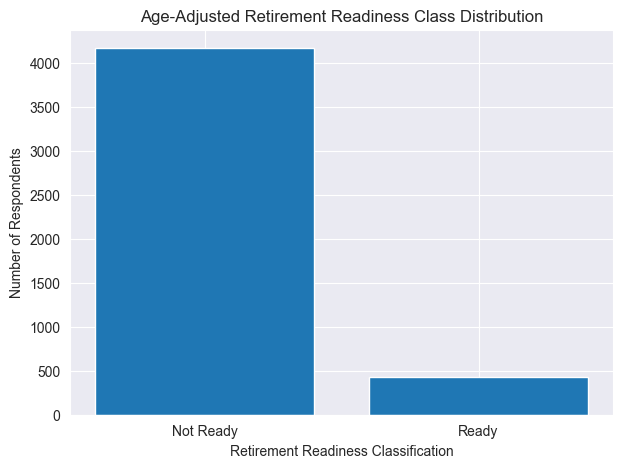

In [99]:
plt.figure(figsize=(7, 5))

ret_ready_counts = df["RET_READY"].value_counts().sort_index()
ret_ready_labels = ["Not Ready", "Ready"]

plt.bar(ret_ready_labels, ret_ready_counts.values)

plt.title("Age-Adjusted Retirement Readiness Class Distribution")
plt.xlabel("Retirement Readiness Classification")
plt.ylabel("Number of Respondents")

plt.show()

The age-adjusted retirement readiness target is highly imbalanced, with most respondents classified as not retirement ready. This supports the use of class-weighted classification models and class-specific evaluation metrics such as precision, recall, and F1-score.

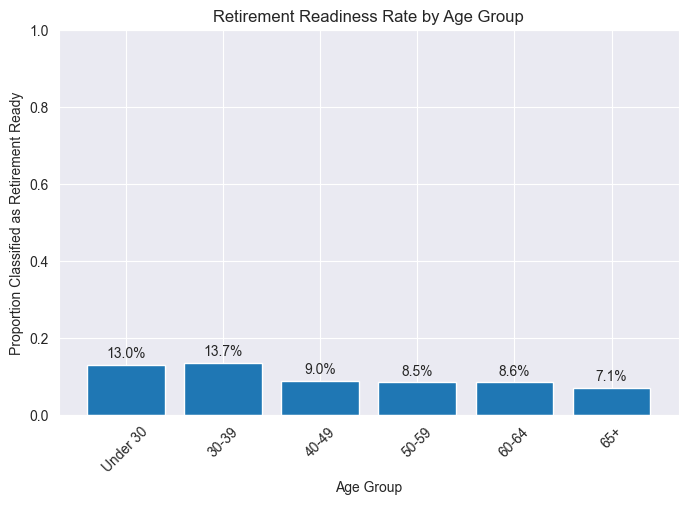

In [140]:
readiness_by_age = (
    df.groupby("AGE_GROUP")["RET_READY"]
      .mean()
      .reindex(["Under 30", "30-39", "40-49", "50-59", "60-64", "65+"])
)

plt.figure(figsize=(8, 5))

bars = plt.bar(readiness_by_age.index, readiness_by_age.values)

plt.title("Retirement Readiness Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Proportion Classified as Retirement Ready")
plt.ylim(0, 1)

plt.xticks(rotation=45)

# Add percentage labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.1%}",
        ha="center",
        va="bottom"
    )

plt.show()

This chart shows the proportion of respondents classified as retirement ready within each age group. Because the readiness threshold increases with age, the chart helps evaluate how the age-adjusted classification rule behaves across different life stages.

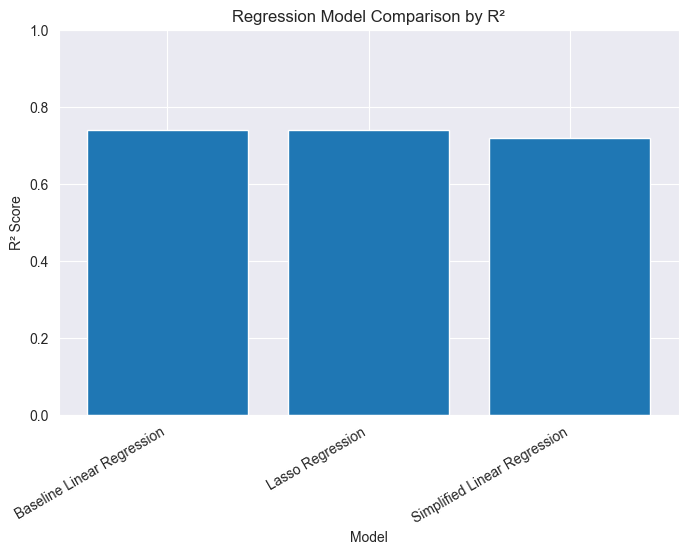

In [141]:
model_comparison_plot = model_comparison.copy()

plt.figure(figsize=(8, 5))

plt.bar(model_comparison_plot["Model"], model_comparison_plot["R2"])

plt.title("Regression Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.xticks(rotation=30, ha="right")

plt.show()

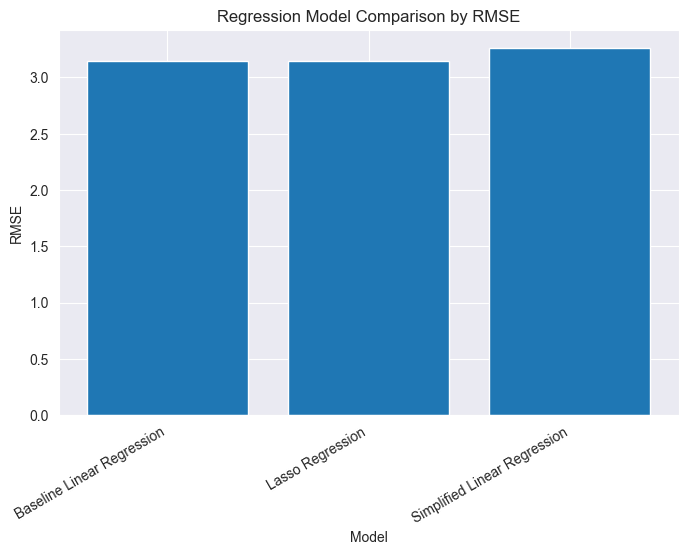

In [142]:
plt.figure(figsize=(8, 5))

plt.bar(model_comparison_plot["Model"], model_comparison_plot["RMSE"])

plt.title("Regression Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=30, ha="right")

plt.show()

The regression model comparison shows that the baseline linear regression and Lasso regression models performed similarly, while the simplified regression model had slightly lower predictive performance. The simplified model remains useful for interpretation, but the baseline and Lasso models retained stronger predictive accuracy.

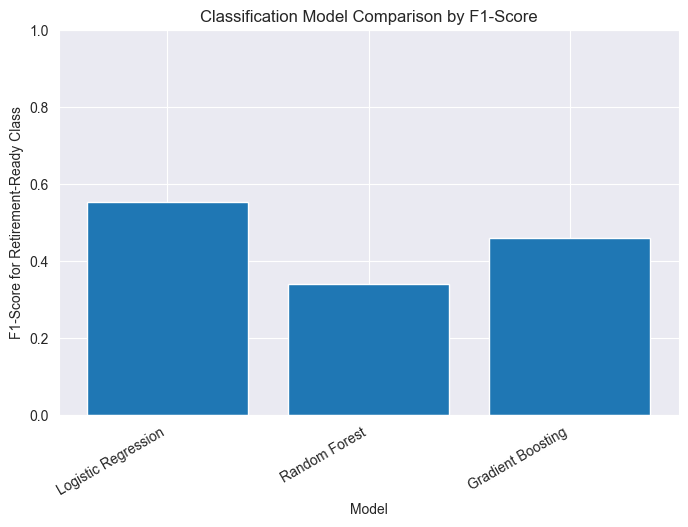

In [143]:
classification_plot = classification_model_comparison.copy()

plt.figure(figsize=(8, 5))

plt.bar(classification_plot["Model"], classification_plot["F1"])

plt.title("Classification Model Comparison by F1-Score")
plt.xlabel("Model")
plt.ylabel("F1-Score for Retirement-Ready Class")
plt.ylim(0, 1)

plt.xticks(rotation=30, ha="right")

plt.show()

The F1-score comparison shows that Logistic Regression produced the strongest overall balance between precision and recall for the retirement-ready class. Although Random Forest and Gradient Boosting had higher precision, their lower recall reduced their F1-scores. This suggests that Logistic Regression was the most effective model for identifying respondents who met the age-adjusted retirement readiness threshold while still maintaining a reasonable balance between false positives and false negatives.

Because the target variable is imbalanced, F1-score provides a more useful comparison than accuracy alone. The chart highlights that models with high accuracy may still perform poorly on the smaller retirement-ready class if they miss too many actual ready respondents.

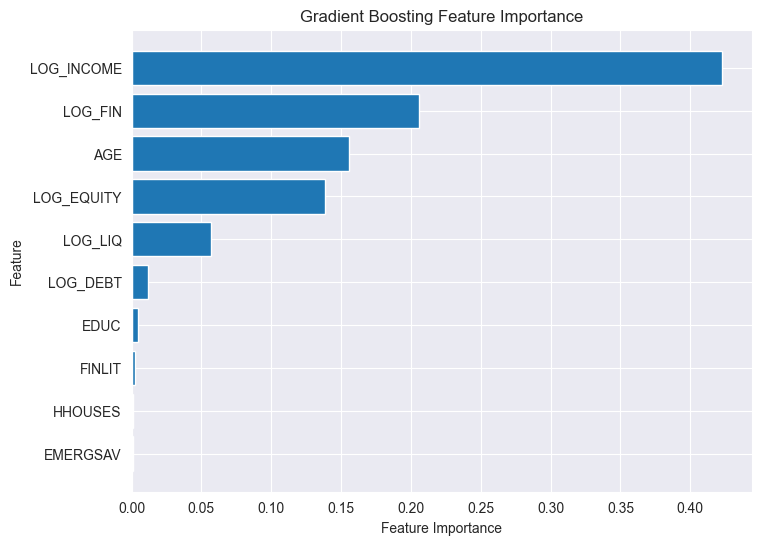

In [104]:
gb_importance = pd.Series(
    gb_clf.feature_importances_,
    index=classification_features
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))

plt.barh(gb_importance.index, gb_importance.values)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

The Gradient Boosting feature importance plot identifies which variables contributed most to the preferred classification model. These results help explain which financial and demographic factors were most useful for predicting whether respondents met the age-adjusted retirement readiness threshold.

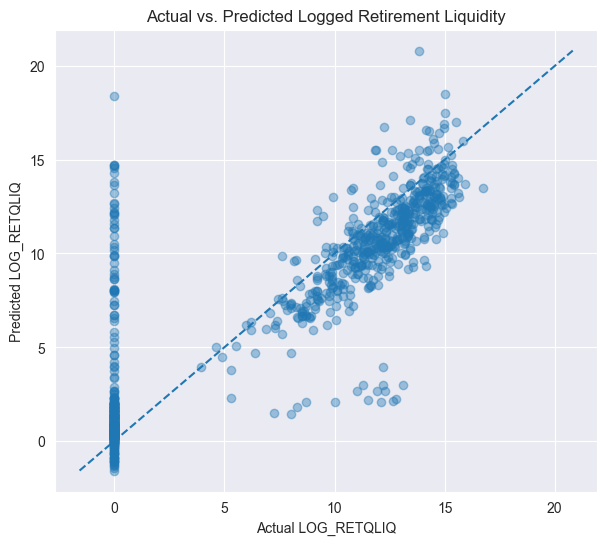

In [105]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("Actual vs. Predicted Logged Retirement Liquidity")
plt.xlabel("Actual LOG_RETQLIQ")
plt.ylabel("Predicted LOG_RETQLIQ")

plt.show()

The actual versus predicted plot shows that the regression model generally captured the upward relationship between observed and predicted logged retirement liquidity. Respondents with moderate to high retirement liquidity formed a clear positive pattern, indicating reasonable predictive performance. However, many respondents with actual logged retirement liquidity of zero were spread across a wide range of predicted values, showing that the model struggled to accurately predict cases with no retirement liquidity. This suggests that while the regression model performed well overall, prediction error was larger among respondents with very low or zero retirement savings.

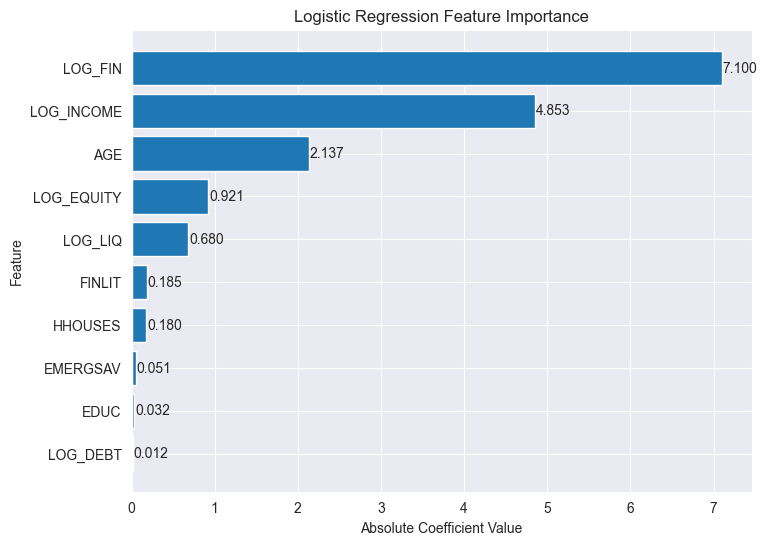

In [144]:
log_coef = pd.Series(
    log_clf.named_steps["model"].coef_[0],
    index=classification_features
)

log_importance = log_coef.abs().sort_values(ascending=True)

plt.figure(figsize=(8, 6))

bars = plt.barh(log_importance.index, log_importance.values)

plt.title("Logistic Regression Feature Importance")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.show()

In [145]:
log_coef_df = pd.DataFrame({
    "Feature": log_coef.index,
    "Coefficient": log_coef.values,
    "Absolute Importance": log_coef.abs().values,
    "Direction": np.where(log_coef.values > 0, "Positive", "Negative")
}).sort_values("Absolute Importance", ascending=False)

log_coef_df

,Feature,Coefficient,Absolute Importance,Direction
1,LOG_FIN,7.100351,7.100351,Positive
3,LOG_INCOME,-4.852549,4.852549,Negative
7,AGE,-2.136554,2.136554,Negative
0,LOG_EQUITY,0.920832,0.920832,Positive
2,LOG_LIQ,-0.680001,0.680001,Negative
6,FINLIT,0.184779,0.184779,Positive
8,HHOUSES,0.179967,0.179967,Positive
9,EMERGSAV,0.051349,0.051349,Positive
5,EDUC,0.031964,0.031964,Positive
4,LOG_DEBT,-0.011691,0.011691,Negative


The Logistic Regression feature importance plot shows that LOG_FIN, LOG_INCOME, and AGE had the largest influence on retirement readiness classification. LOG_FIN had the strongest positive coefficient, meaning higher financial assets were associated with a greater likelihood of being classified as retirement ready. LOG_INCOME and AGE had large negative coefficients, suggesting that higher income and older age made the readiness threshold harder to meet because the age-adjusted target was based on income multiples that increase with age. Other variables, including FINLIT, HHOUSES, EMERGSAV, EDUC, and LOG_DEBT, had much smaller coefficient values, indicating weaker influence in the Logistic Regression model.

Because these values are standardized Logistic Regression coefficients, they should be interpreted by relative size and direction rather than as raw dollar effects.

ROC-AUC was used as an additional evaluation metric to assess each model’s ability to distinguish between respondents who were retirement ready and those who were not. Unlike accuracy, ROC-AUC evaluates model performance across different classification thresholds. However, because the retirement-ready class was much smaller than the not-ready class, precision, recall, F1-score, and the confusion matrix remained more important for interpreting practical classification performance.

In [147]:
# probabilities for the positive class: RET_READY = 1
y_prob_log = log_clf.predict_proba(X_test_cls)[:, 1]
y_prob_rf = rf_clf.predict_proba(X_test_cls)[:, 1]
y_prob_gb = gb_clf.predict_proba(X_test_cls)[:, 1]

auc_log = roc_auc_score(y_test_cls, y_prob_log)
auc_rf = roc_auc_score(y_test_cls, y_prob_rf)
auc_gb = roc_auc_score(y_test_cls, y_prob_gb)

roc_auc_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "ROC_AUC": [auc_log, auc_rf, auc_gb]
})

roc_auc_comparison

,Model,ROC_AUC
0,Logistic Regression,0.948611
1,Random Forest,0.938524
2,Gradient Boosting,0.949937


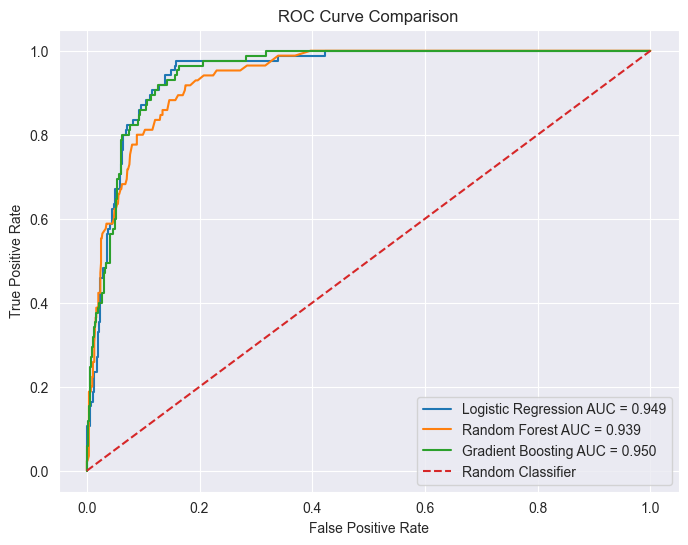

In [148]:
fpr_log, tpr_log, _ = roc_curve(y_test_cls, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test_cls, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test_cls, y_prob_gb)

plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression AUC = {auc_log:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_rf:.3f}")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting AUC = {auc_gb:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

The ROC-AUC results show that all three classification models were effective at distinguishing between respondents who were retirement ready and those who were not. Gradient Boosting had the highest ROC-AUC score at 0.950, followed closely by Logistic Regression at 0.949 and Random Forest at 0.939. Since all three models scored well above 0.50, each model performed substantially better than random classification.

However, ROC-AUC should be interpreted as a supporting metric rather than the primary model-selection metric since the retirement-ready class was imbalanced. Although Gradient Boosting had the highest ROC-AUC, Logistic Regression produced the strongest F1-score and recall for the retirement-ready class in the classification comparison. Therefore, ROC-AUC confirms that the models have strong separation ability, while precision, recall, F1-score, and the confusion matrix provide the clearest view of practical classification performance.